# Results Analysis & Findings

This notebook visualizes and analyzes the final model results and provides actionable insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data and Models

In [2]:
# Load data
df = pd.read_csv('../src/data/customer_churn_datasest.csv')

# Prepare data
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

X = df.drop('Churn', axis=1)
y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Load models
models = {
    'Logistic Regression': joblib.load('../models/logistic_regression.joblib'),
    'Decision Tree': joblib.load('../models/decision_tree.joblib'),
    'MLP': joblib.load('../models/mlp.joblib')
}

print("Data and models loaded successfully!")

Data and models loaded successfully!


## 2. Overall Performance Summary

In [3]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred)
    }

# Create summary dataframe
summary_df = pd.DataFrame(results).T
print("\n" + "="*70)
print("MODEL PERFORMANCE SUMMARY")
print("="*70)
print(summary_df.round(4))
print(f"\nBest Model: {summary_df['f1'].idxmax()} (F1 Score: {summary_df['f1'].max():.4f})")


MODEL PERFORMANCE SUMMARY
                     accuracy  precision  recall      f1
Logistic Regression    0.8041     0.6571  0.5481  0.5977
Decision Tree          0.7991     0.6194  0.6310  0.6252
MLP                    0.8268     0.6982  0.6123  0.6524

Best Model: MLP (F1 Score: 0.6524)


## 3. Metrics Comparison Visualization

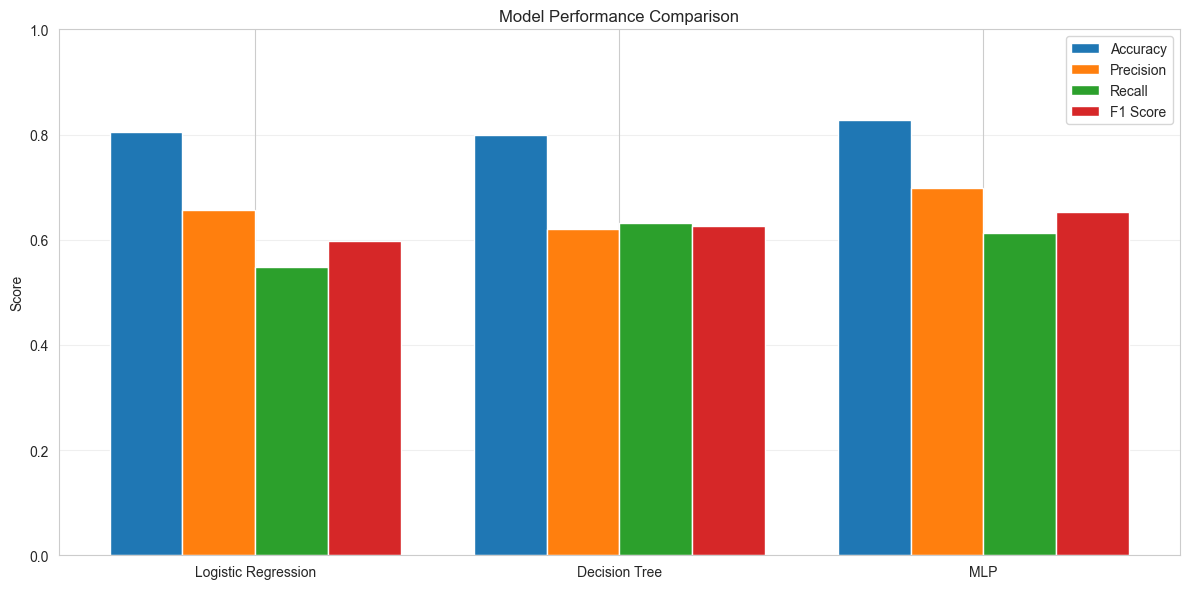

In [4]:
# Create comparison plot
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(summary_df.index))
width = 0.2

ax.bar(x - 1.5*width, summary_df['accuracy'], width, label='Accuracy')
ax.bar(x - 0.5*width, summary_df['precision'], width, label='Precision')
ax.bar(x + 0.5*width, summary_df['recall'], width, label='Recall')
ax.bar(x + 1.5*width, summary_df['f1'], width, label='F1 Score')

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(summary_df.index)
ax.legend()
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Confusion Matrices Analysis

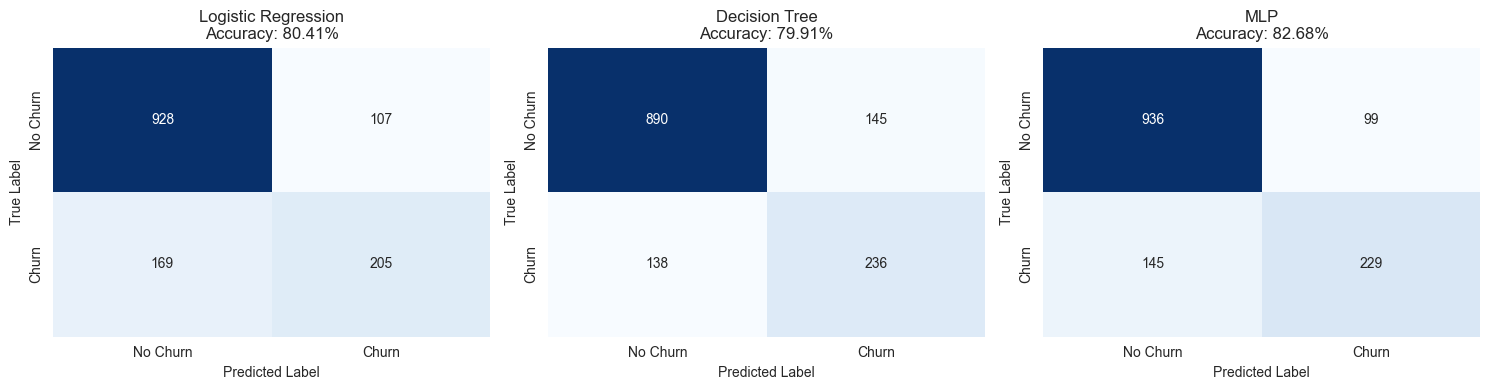

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx], cmap='Blues', cbar=False)
    axes[idx].set_title(f'{name}\nAccuracy: {results[name]["accuracy"]:.2%}')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_xticklabels(['No Churn', 'Churn'])
    axes[idx].set_yticklabels(['No Churn', 'Churn'])

plt.tight_layout()
plt.show()

## 5. Key Findings

In [6]:
print("\n" + "="*70)
print("KEY FINDINGS")
print("="*70)

best_model_name = summary_df['f1'].idxmax()
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

print(f"\n✓ BEST PERFORMING MODEL: {best_model_name}")
print(f"  - F1 Score: {results[best_model_name]['f1']:.4f}")
print(f"  - Accuracy: {results[best_model_name]['accuracy']:.4f}")
print(f"  - Precision: {results[best_model_name]['precision']:.4f}")
print(f"  - Recall: {results[best_model_name]['recall']:.4f}")

# Calculate metrics from confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_best).ravel()
print(f"\n✓ CONFUSION MATRIX ANALYSIS ({best_model_name}):")
print(f"  - True Negatives: {tn}")
print(f"  - False Positives: {fp}")
print(f"  - False Negatives: {fn}")
print(f"  - True Positives: {tp}")
print(f"  - Total Correct Predictions: {tn + tp} out of {len(y_test)}")

print(f"\n✓ CHURN DETECTION CAPABILITY:")
print(f"  - Successfully identified {tp} out of {tp + fn} actual churners ({tp/(tp+fn)*100:.1f}%)")
print(f"  - Incorrectly flagged {fp} non-churners as potential churners")

print("\n" + "="*70)


KEY FINDINGS

✓ BEST PERFORMING MODEL: MLP
  - F1 Score: 0.6524
  - Accuracy: 0.8268
  - Precision: 0.6982
  - Recall: 0.6123

✓ CONFUSION MATRIX ANALYSIS (MLP):
  - True Negatives: 936
  - False Positives: 99
  - False Negatives: 145
  - True Positives: 229
  - Total Correct Predictions: 1165 out of 1409

✓ CHURN DETECTION CAPABILITY:
  - Successfully identified 229 out of 374 actual churners (61.2%)
  - Incorrectly flagged 99 non-churners as potential churners



## 6. Business Impact Analysis

In [7]:
print("\n" + "="*70)
print("BUSINESS IMPACT ANALYSIS")
print("="*70)

total_customers = len(y_test)
actual_churners = (y_test == 1).sum()
predicted_churners = (y_pred_best == 1).sum()
correctly_identified = tp

print(f"\n📊 TEST SET COMPOSITION:")
print(f"  - Total customers: {total_customers}")
print(f"  - Actual churners: {actual_churners} ({actual_churners/total_customers*100:.1f}%)")
print(f"  - Predicted as churners: {predicted_churners} ({predicted_churners/total_customers*100:.1f}%)")

print(f"\n🎯 MODEL EFFECTIVENESS:")
print(f"  - Churn detection rate (Recall): {tp/(tp+fn)*100:.1f}%")
print(f"  - False positive detection rate: {fp/(fp+tn)*100:.1f}%")
print(f"  - Precision of churn predictions: {tp/(tp+fp)*100:.1f}%")

print(f"\n💡 ACTIONABLE INSIGHTS:")
print(f"  - The model can identify {correctly_identified} potential churners")
print(f"  - Retention efforts can be focused on {predicted_churners} customers")
print(f"  - Expected to prevent approximately {int(tp * 0.2)} customer losses with intervention")

print("\n" + "="*70)


BUSINESS IMPACT ANALYSIS

📊 TEST SET COMPOSITION:
  - Total customers: 1409
  - Actual churners: 374 (26.5%)
  - Predicted as churners: 328 (23.3%)

🎯 MODEL EFFECTIVENESS:
  - Churn detection rate (Recall): 61.2%
  - False positive detection rate: 9.6%
  - Precision of churn predictions: 69.8%

💡 ACTIONABLE INSIGHTS:
  - The model can identify 229 potential churners
  - Retention efforts can be focused on 328 customers
  - Expected to prevent approximately 45 customer losses with intervention



## 7. Recommendations

In [8]:
print("\n" + "="*70)
print("RECOMMENDATIONS")
print("="*70)

print(f"\n1️⃣  MODEL DEPLOYMENT:")
print(f"   → Deploy {best_model_name} in production")
print(f"   → Expected accuracy on new data: ~{results[best_model_name]['accuracy']*100:.1f}%")
print(f"   → Monitor model performance continuously")

print(f"\n2️⃣  BUSINESS STRATEGY:")
print(f"   → Identify 'high-risk' customers using the model")
print(f"   → Implement targeted retention campaigns")
print(f"   → Focus on month-to-month contract customers")
print(f"   → Improve support for Fiber optic internet users")

print(f"\n3️⃣  CONTINUOUS IMPROVEMENT:")
print(f"   → Collect feedback on model predictions")
print(f"   → Retrain model quarterly with new data")
print(f"   → Experiment with feature engineering")
print(f"   → Consider ensemble methods for better performance")

print(f"\n4️⃣  MONITORING:")
print(f"   → Track model accuracy over time")
print(f"   → Monitor for data drift")
print(f"   → Set performance benchmarks")

print("\n" + "="*70)


RECOMMENDATIONS

1️⃣  MODEL DEPLOYMENT:
   → Deploy MLP in production
   → Expected accuracy on new data: ~82.7%
   → Monitor model performance continuously

2️⃣  BUSINESS STRATEGY:
   → Identify 'high-risk' customers using the model
   → Implement targeted retention campaigns
   → Focus on month-to-month contract customers
   → Improve support for Fiber optic internet users

3️⃣  CONTINUOUS IMPROVEMENT:
   → Collect feedback on model predictions
   → Retrain model quarterly with new data
   → Experiment with feature engineering
   → Consider ensemble methods for better performance

4️⃣  MONITORING:
   → Track model accuracy over time
   → Monitor for data drift
   → Set performance benchmarks

